<a href="https://colab.research.google.com/github/kimve1969/mgu_ds_cours/blob/main/semestr%202.1/task%202/semestr_2_1_task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ВМК МГУ, Курс по Data Science (DS) и Machine Learning (ML) 2026 год
2 семестр, Анализ данных в Python,
Ким Виталий Евгеньевич, ПАО "Сургутнефтегаз"
21.07.2026

В этом задании мы будем использовать общедоступные данные о подсчете велосипедов в городе Гент (Бельгия). В Coupure Links, рядом с Факультетом инженерии биологических наук, счетчик отслеживает количество проезжающих велосипедистов в обоих направлениях.

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
#plt.style.available

Этот набор данных содержит исторические данные счетчиков велосипедов и состоит из следующих столбцов: Дата в первом столбце — это дата в формате дд/мм/гг . Второй столбец tijd — это время суток в формате чч:мм. Третий и четвертый столбцы ri Centrum и ri Mariakerke — это счетчики на тот момент времени (счетчики между этой отметкой времени и предыдущей).

In [36]:
df_raw = pd.read_csv('https://raw.githubusercontent.com/kimve1969/mgu_ds_cours/refs/heads/main/semestr%202.1/task%202/fietstellingencoupure.csv', sep = ';')
df_raw

,datum,tijd,ri Centrum,ri Mariakerke
0,14/07/2011,17:44,21,46
1,14/07/2011,17:59,17,60
2,14/07/2011,18:14,13,48
3,14/07/2011,18:29,22,48
4,14/07/2011,18:44,15,51
...,...,...,...,...
191442,18/01/2017,22:54,16,32
191443,18/01/2017,23:09,8,22
191444,18/01/2017,23:24,10,29
191445,18/01/2017,23:39,11,31


# Обработка данных
Как объяснялось выше, первый и второй столбцы (соответственно datum и tijd ) указывают дату и час дня. Чтобы получить временной ряд, мы должны объединить эти два столбца в один ряд фактических значений временных меток.

## УПРАЖНЕНИЕ 2
Предварительно обработайте данные: Объедините столбцы «datum» и «tijd» в одну серию Pandas строковых значений даты и времени, назовите эту новую переменную совмещенной . Разберите строковые значения даты и времени на объекты даты и времени. Установите результирующий столбец даты и времени в качестве индекса df DataFrame. Удалите исходные столбцы «datum» и «tijd», используя метод drop , и вызовите новый кадр данных df2 . Переименуйте столбцы в DataFrame «ri Centrum», «ri Mariakerke» соответственно. 'direction_centre', 'direction_mariakerke' с использованием метода переименования .

In [38]:
def process_bike_count_data(df):
  df['datum_tijd'] = pd.to_datetime(df['datum'] +' '+ df['tijd'], format='%d/%m/%Y %H:%M')
  df.drop(labels=['datum','tijd'], axis=1, inplace=True)
  df.set_index('datum_tijd')
  df.rename(columns={'ri Centrum':'direction_centre', 'ri Mariakerke':'direction_mariakerke'}, inplace=True)
  return df

In [39]:
df = process_bike_count_data(df_raw)
df.head()

,direction_centre,direction_mariakerke,datum_tijd
0,21,46,2011-07-14 17:44:00
1,17,60,2011-07-14 17:59:00
2,13,48,2011-07-14 18:14:00
3,22,48,2011-07-14 18:29:00
4,15,51,2011-07-14 18:44:00


Наличие данных, доступных с интерпретируемым datetime , дает нам возможность иметь график с учетом времени:

<Axes: >

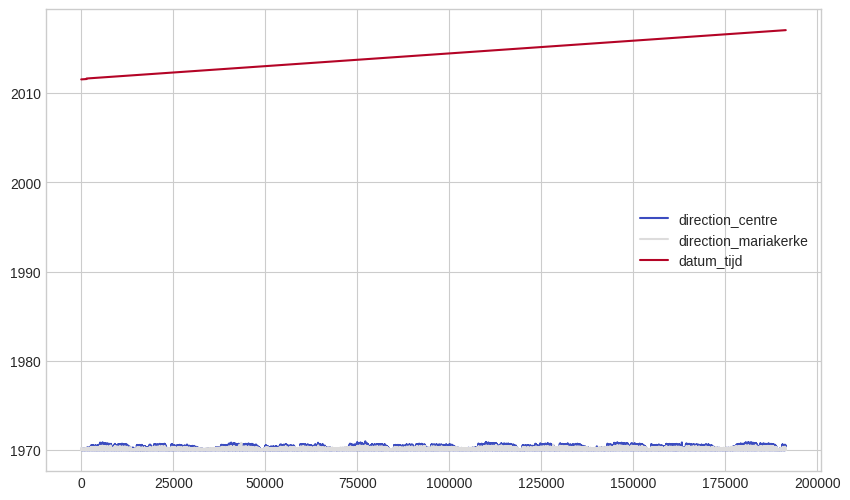

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))
df.plot(colormap='coolwarm', ax=ax)

Храните наш собранный набор данных в качестве промежуточного продукта данных Когда мы завершили этап сбора данных, мы хотим сохранить этот результат в качестве промежуточного вывода данных нашего небольшого исследования. Таким образом, нам не нужно повторно загружать все файлы каждый раз, когда что-то пойдет не так, но мы можем начать заново с нашего промежуточного шага.

In [41]:
df.to_csv("bike_count_interim.csv")

# 3. Исследование и анализ данных
Теперь у нас есть очищенный набор данных о подсчете велосипедов в Coupure Links в Генте (Бельгия). Далее мы хотим получить представление о характеристиках и свойствах данных.

## Загрузите промежуточные данные
Чтение файла из промежуточного файла (если вы хотите повторить весь анализ обновленных онлайн-данных, вы должны закомментировать эту ячейку...)

In [42]:
df = pd.read_csv("bike_count_interim.csv", index_col='datum_tijd', parse_dates=True)
df

,Unnamed: 0,direction_centre,direction_mariakerke
datum_tijd,,,
2011-07-14 17:44:00,0,21,46
2011-07-14 17:59:00,1,17,60
2011-07-14 18:14:00,2,13,48
2011-07-14 18:29:00,3,22,48
2011-07-14 18:44:00,4,15,51
...,...,...,...
2017-01-18 22:54:00,191442,16,32
2017-01-18 23:09:00,191443,8,22
2017-01-18 23:24:00,191444,10,29


Проверка интервала подсчета Количество байкеров подсчитывается с интервалом примерно в 15 минут. Но давайте проверим, так ли это на самом деле. Вычислите разницу между каждым из последовательных значений индекса. Мы можем использовать метод Series.diff() :

In [43]:
pd.Series(df.index).diff()

,datum_tijd
0,NaT
1,0 days 00:15:00
2,0 days 00:15:00
3,0 days 00:15:00
4,0 days 00:15:00
...,...
191442,0 days 00:15:00
191443,0 days 00:15:00
191444,0 days 00:15:00
191445,0 days 00:15:00


Представляет интерес количество возможных интервалов:

In [44]:
pd.Series(df.index).diff().value_counts()

,count
datum_tijd,
0 days 00:15:00,191356
0 days 00:16:00,9
0 days 00:13:00,6
-1 days +23:15:00,6
0 days 00:09:00,6
0 days 01:15:00,5
0 days 00:04:00,5
0 days 00:11:00,4
0 days 00:12:00,4


Есть несколько записей, которые не ровно 15 минут. Но, учитывая, что их всего несколько, мы проигнорируем их для текущего тематического исследования и просто сохраним их для этого исследовательского исследования.

In [45]:
df.describe()

,Unnamed: 0,direction_centre,direction_mariakerke
count,191447.00000,191447.000000,191447.000000
mean,95723.00000,25.545237,25.338585
std,55266.13283,31.625619,26.903810
min,0.00000,0.000000,0.000000
25%,47861.50000,5.000000,7.000000
50%,95723.00000,17.000000,17.000000
75%,143584.50000,34.000000,34.000000
max,191446.00000,361.000000,299.000000


## УПРАЖНЕНИЕ 4
Создайте новый ряд Pandas df_both , который содержит сумму значений обоих направлений.

In [46]:
df['direction_both'] = df['direction_centre'] + df['direction_mariakerke']
df_both = df.copy()
df_both

,Unnamed: 0,direction_centre,direction_mariakerke,direction_both
datum_tijd,,,,
2011-07-14 17:44:00,0,21,46,67
2011-07-14 17:59:00,1,17,60,77
2011-07-14 18:14:00,2,13,48,61
2011-07-14 18:29:00,3,22,48,70
2011-07-14 18:44:00,4,15,51,66
...,...,...,...,...
2017-01-18 22:54:00,191442,16,32,48
2017-01-18 23:09:00,191443,8,22,30
2017-01-18 23:24:00,191444,10,29,39


## УПРАЖНЕНИЕ 5
Используя df_both из предыдущего упражнения, создайте новую серию df_quiet , содержащую только те интервалы, за которые в сумме в обоих направлениях проехало менее 5 велосипедистов .

In [47]:
df_quiet = df_both[ df_both['direction_both'] < 5]
df_quiet

,Unnamed: 0,direction_centre,direction_mariakerke,direction_both
datum_tijd,,,,
2011-07-15 00:59:00,29,0,4,4
2011-07-15 01:44:00,32,1,2,3
2011-07-15 02:29:00,35,0,0,0
2011-07-15 02:44:00,36,0,1,1
2011-07-15 02:59:00,37,1,0,1
...,...,...,...,...
2017-01-18 04:39:00,191369,1,3,4
2017-01-18 05:24:00,191372,3,1,4
2017-01-18 05:39:00,191373,1,0,1


## УПРАЖНЕНИЕ 6
По исходным данным df выбрать только те интервалы, за которые в том или ином направлении проехало менее 3 велосипедистов. Следовательно, менее 3 велосипедистов в сторону центра или менее 3 велосипедистов в сторону Мариакерке.

In [48]:
df[ (df['direction_centre'] < 3) | (df['direction_mariakerke'] < 3)]

,Unnamed: 0,direction_centre,direction_mariakerke,direction_both
datum_tijd,,,,
2011-07-14 23:59:00,25,1,13,14
2011-07-15 00:14:00,26,2,3,5
2011-07-15 00:44:00,28,2,6,8
2011-07-15 00:59:00,29,0,4,4
2011-07-15 01:29:00,31,1,10,11
...,...,...,...,...
2017-01-18 06:09:00,191375,2,2,4
2017-01-18 06:24:00,191376,7,1,8
2017-01-18 06:39:00,191377,2,2,4


# Считать статистику

## УПРАЖНЕНИЕ 7
Какое среднее количество велосипедистов проезжает каждые 15 минут?

In [15]:
# Сбрасываем индекс, иначе к полю datum_tijd нельзя обратиться как к столбцу
# df.reset_index(inplace=True)

In [68]:
# группируем по 15 минутным интервалам
df_15min = df.groupby( by=df.index.strftime('%H:%M') ).agg({'direction_centre':'sum',
                                                            'direction_mariakerke':'sum',
                                                            'direction_both':'sum'}).copy()

## УПРАЖНЕНИЕ 8

Какое среднее количество велосипедистов проезжает каждый час?

In [70]:
# группируем по часовым интервалам
df_hours = df.groupby( by=df.index.strftime('%H') ).agg({'direction_centre':'sum',
                                                            'direction_mariakerke':'sum',
                                                            'direction_both':'sum'}).copy()

## УПРАЖНЕНИЕ 9

Каковы 10 самых высоких пиковых значений, наблюдаемых в течение любого из интервалов для направления к центру Гента?

In [81]:
df_15min_top10 = df_15min.sort_values('direction_centre', ascending=False).head(10).copy()
df_15min_top10

,direction_centre,direction_mariakerke,direction_both
datum_tijd,,,
08:27,31381,13093,44474
08:42,27577,8904,36481
08:12,26664,9541,36205
08:55,23369,7385,30754
08:37,23299,7349,30648
08:20,22576,7032,29608
08:40,22036,9294,31330
08:50,21541,7969,29510
08:25,21239,7929,29168


In [82]:
df_hours_top10 = df_hours.sort_values('direction_centre', ascending=False).head(10).copy()
df_hours_top10

,direction_centre,direction_mariakerke,direction_both
datum_tijd,,,
08,710465,244447,954912
09,498442,224914,723356
17,316486,540462,856948
18,298195,552755,850950
07,280860,71018,351878
16,279370,399008,678378
13,273390,266630,540020
10,265059,166179,431238
19,243866,377559,621425


## УПРАЖНЕНИЕ 10

Какое максимальное количество велосипедистов проехало за один день в обоих направлениях вместе взятых? Большое количество байкеров, проехавших 05.06.2013, не случайно: УПРАЖНЕНИЕ 11 http://www.nieuwsblad.be/cnt/dmf20130605_022 ;-)

In [91]:
df_days = df.groupby( by=df.index.strftime('%Y-%m-%d') ).agg({'direction_centre':'sum',
                                                            'direction_mariakerke':'sum',
                                                            'direction_both':'sum'}).copy()
df_days[ df_days['direction_both'] == df_days['direction_both'].max() ]

,direction_centre,direction_mariakerke,direction_both
datum_tijd,,,
2016-09-29,5105,5665,10770


## УПРАЖНЕНИЕ 11

Как выглядит долгосрочный тренд? Рассчитайте ежемесячные суммы и постройте график результата.

In [92]:
df_mounths = df.groupby( by=df.index.strftime('%m') ).agg({'direction_centre':'sum',
                                                            'direction_mariakerke':'sum',
                                                            'direction_both':'sum'}).copy()
df_mounths

,direction_centre,direction_mariakerke,direction_both
datum_tijd,,,
01,334374,326382,660756
02,329415,324331,653746
03,428943,424916,853859
04,365676,363260,728936
05,392505,388203,780708
06,375252,369386,744638
07,299083,291616,590699
08,325464,319665,645129
09,513161,513432,1026593


<Axes: xlabel='datum_tijd'>

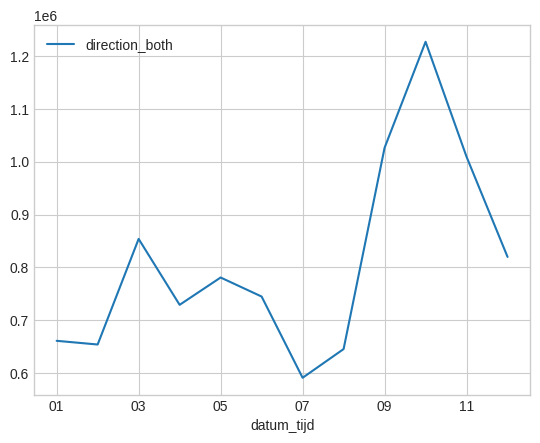

In [94]:
df_mounths.plot(y='direction_both')

## УПРАЖНЕНИЕ 12

Давайте посмотрим на некоторые краткосрочные модели. Для данных за первые 3 недели января 2014 г. рассчитайте почасовые подсчеты и визуализируйте их.

<Axes: xlabel='datum_tijd'>

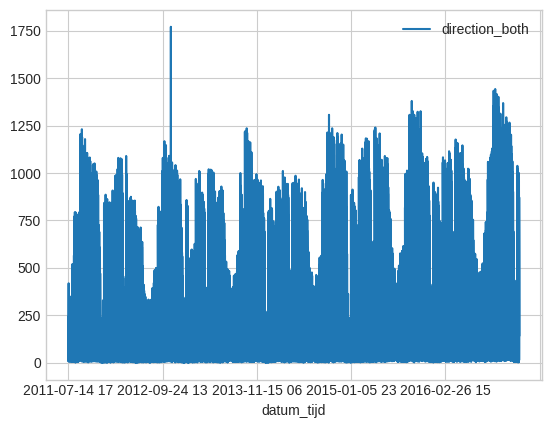

In [101]:
df_01012014_21012014 = df[ (df.index > pd.to_datetime('01.01.2014 00:00:00', format='%d.%m.%Y %H:%M:%S')) &
    (df.index < pd.to_datetime('21.01.2014 23:59:00', format='%d.%m.%Y %H:%M:%S')) ]

df_01012014_21012014_hours = df.groupby( by=df.index.strftime('%Y-%m-%d %H') ).agg({'direction_centre':'sum',
                                                            'direction_mariakerke':'sum',
                                                            'direction_both':'sum'}).copy()

df_01012014_21012014_hours.plot(y='direction_both')

## Новый год 2013-2014 УПРАЖНЕНИЕ 13

Выберите подмножество набора данных с 2013-12-31 12:00:00 до 2014-01-01 12:00:00 и назначьте результат новой переменной newyear. Постройте выбранные данные newyear . Используйте скользящую функцию с окном из 10 значений (см. документацию по функции), чтобы сгладить данные за этот период и построить график сглаженной версии.

<Axes: xlabel='datum_tijd'>

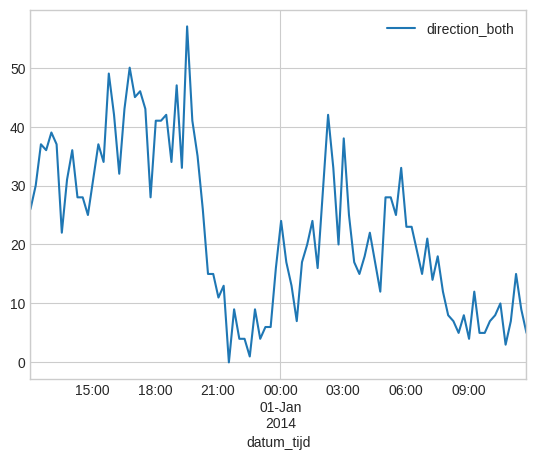

In [104]:
df_2013_2014 = df[ (df.index > pd.to_datetime('2013-12-31 12:00:00', format='%Y-%m-%d %H:%M:%S')) &
    (df.index < pd.to_datetime('2014-01-01 12:00:00', format='%Y-%m-%d %H:%M:%S')) ].copy()

df_2013_2014.plot(y='direction_both')

<Axes: xlabel='datum_tijd'>

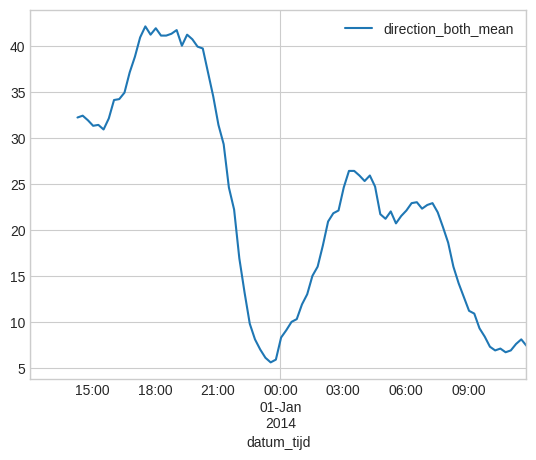

In [105]:
# Сглаженный график
df_2013_2014['direction_both_mean'] = df_2013_2014['direction_both'].rolling(10).mean()
df_2013_2014.plot(y='direction_both_mean')